In [40]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [41]:
import pandas as pd
import numpy as np
import timesfm
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.timesfm_wrapper import TimesFMForecaster
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [42]:
DATA_DIR

'../data'

In [43]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [44]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [45]:
hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
checkpoint = timesfm.TimesFmCheckpoint(version = "torch", huggingface_repo_id="google/timesfm-1.0-200m-pytorch")
forecaster = timesfm.TimesFm(hparams = hparams, checkpoint=checkpoint)

Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3565.57it/s]


In [46]:
debug = False

In [47]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    forecaster = TimesFMForecaster(hparams = hparams)


        
    for symbol in crypto_symbols:
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")


        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print(f"test_history\n{test_history}")
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

0fd77f45-6233-43f7-9de2-04c577fb8316


Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3403.55it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 23.25106978416443 seconds


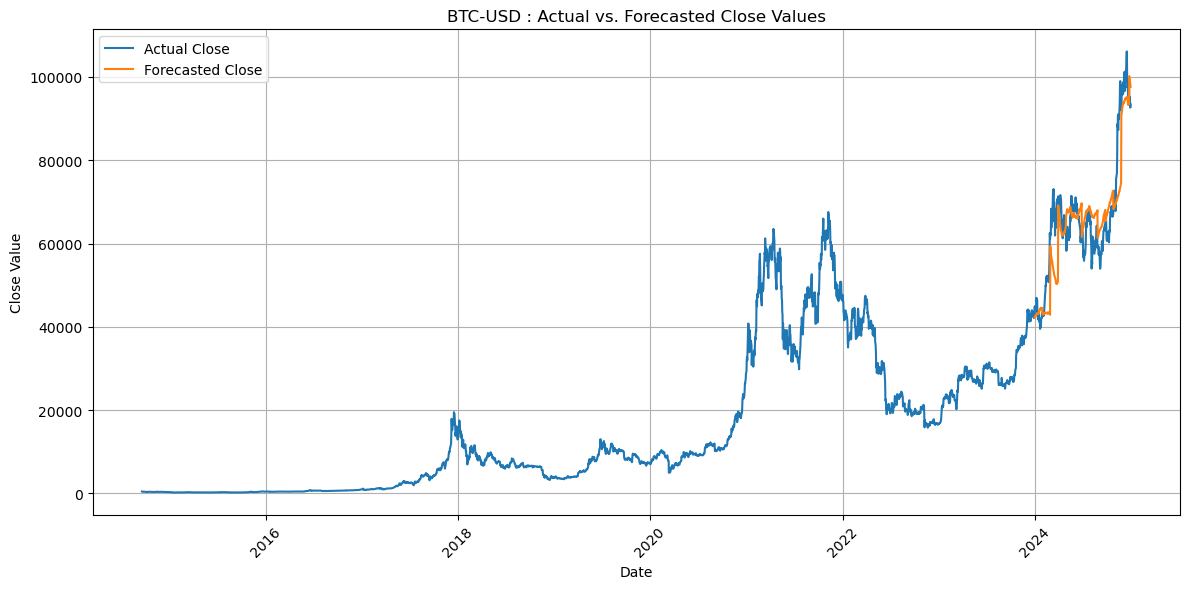

Evaluation Metric for BTC-USD_timesfm_30 Actual Values
MAPE: 8.656824377564092
ME: 1181.7174372438524
MAE: 5763.323674436476
MPE: 0.9924365915432917
RMSE: 7723.232786585596
R: 0.8564552130422356
Scalar Product: 12408412.008376975
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857


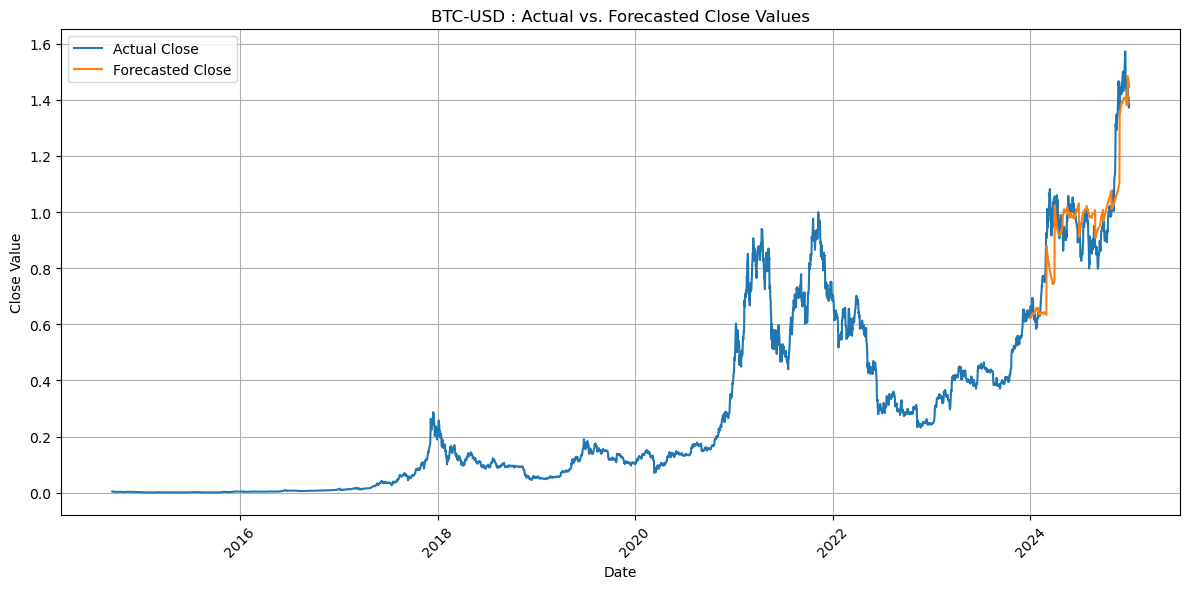

Evaluation Metric for BTC-USD_timesfm_30 Scaled
MAPE: 8.681056667182363
ME: 0.017535819820378776
MAE: 0.08552356147555457
MPE: 0.9933490260527036
RMSE: 0.11460719204908452
R: 0.856455223175118
Scalar Product: 0.0027323555079269268
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857
Execution time for forecast_crypto_prices(): 44.92966651916504 seconds


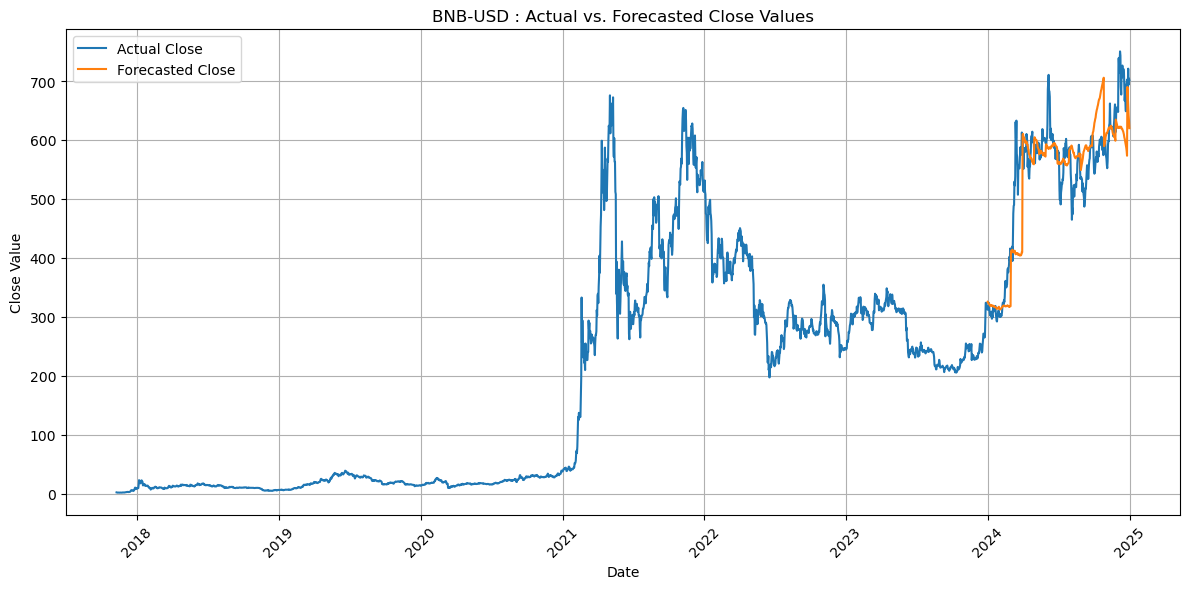

Evaluation Metric for BNB-USD_timesfm_30 Actual Values
MAPE: 8.01147930109921
ME: 7.599928808993981
MAE: 44.53968660948706
MPE: 0.9084872139480368
RMSE: 63.01313048139141
R: 0.8439533435542818
Scalar Product: -3356.594672926686
Return Score: 0.473972602739726
Long Return: 0.4607329842931937
Short Return: 0.4885057471264368
Mean Directional Accuracy: 0.473972602739726
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4885057471264368


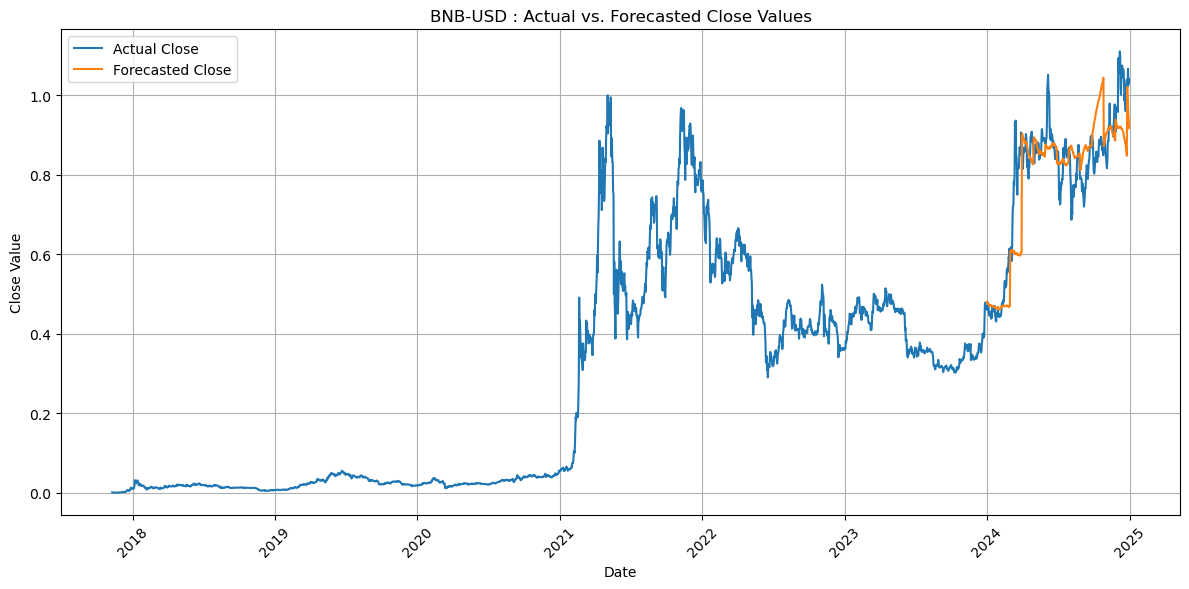

Evaluation Metric for BNB-USD_timesfm_30 Scaled
MAPE: 8.034259562076036
ME: 0.011272941559598406
MAE: 0.06606559378563545
MPE: 0.9098016132406989
RMSE: 0.09346719966864996
R: 0.8439533418571996
Scalar Product: -0.0073850672272516345
Return Score: 0.473972602739726
Long Return: 0.4607329842931937
Short Return: 0.4885057471264368
Mean Directional Accuracy: 0.473972602739726
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4885057471264368
Execution time for forecast_crypto_prices(): 66.43817520141602 seconds


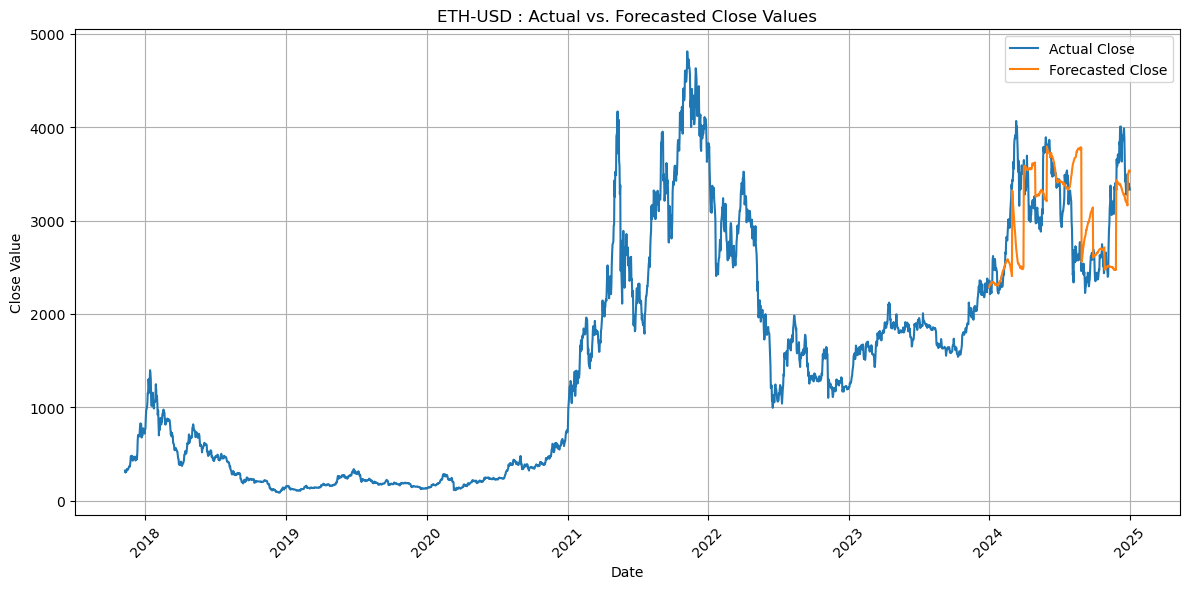

Evaluation Metric for ETH-USD_timesfm_30 Actual Values
MAPE: 12.736069773582829
ME: 1.6118137380464481
MAE: 385.35686822276296
MPE: -1.518131363444941
RMSE: 517.3721588393718
R: 0.4552887294626578
Scalar Product: -26700.193943320774
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193


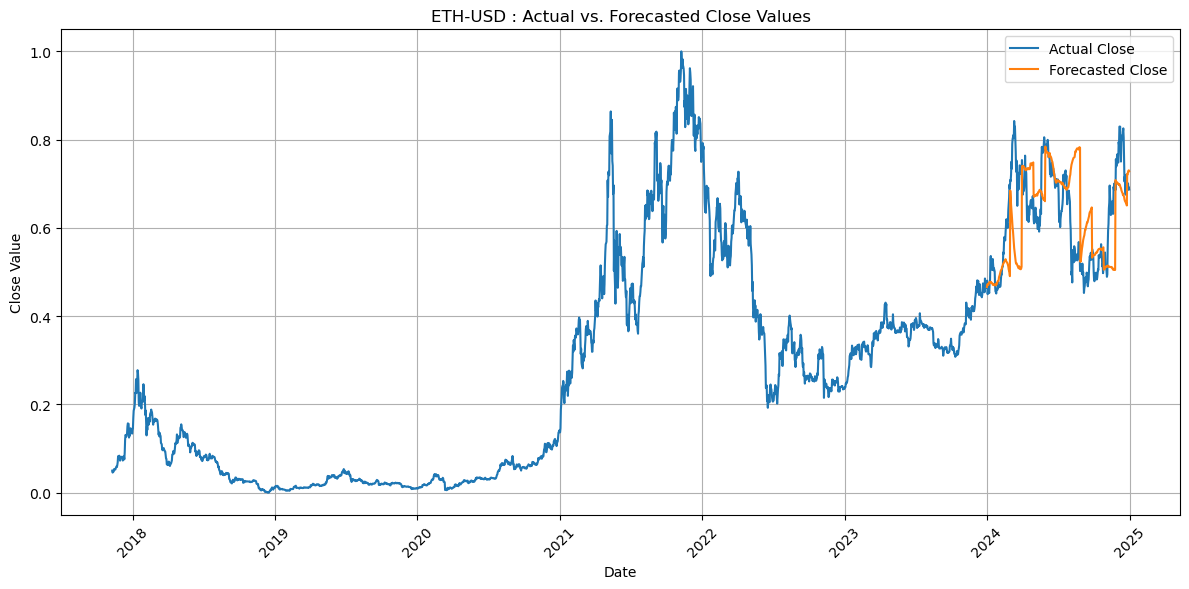

Evaluation Metric for ETH-USD_timesfm_30 Scaled
MAPE: 13.112339926301647
ME: 0.0003409075184576838
MAE: 0.08150907029540141
MPE: -1.6090463300540432
RMSE: 0.10943239001304948
R: 0.45528873195105185
Scalar Product: -0.0011945524975091222
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193
Execution time for forecast_crypto_prices(): 87.9130494594574 seconds


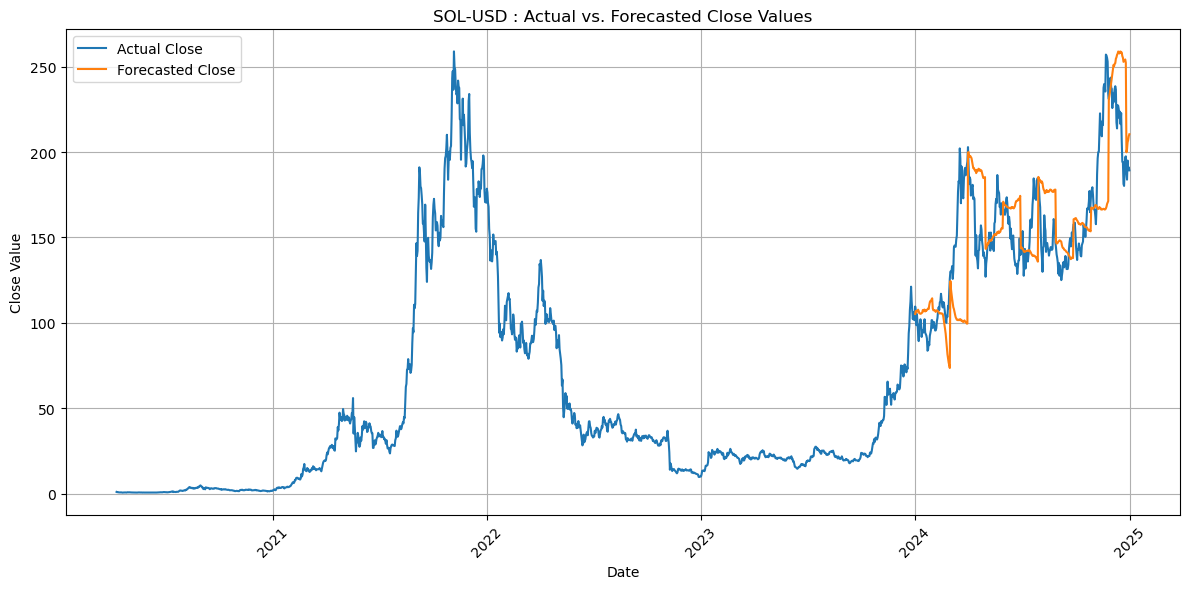

Evaluation Metric for SOL-USD_timesfm_30 Actual Values
MAPE: 14.97811483564086
ME: -0.4801863790209834
MAE: 24.00867036913262
MPE: -1.810529953698363
RMSE: 32.68405721980627
R: 0.6547066435448758
Scalar Product: 1910.939611373706
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


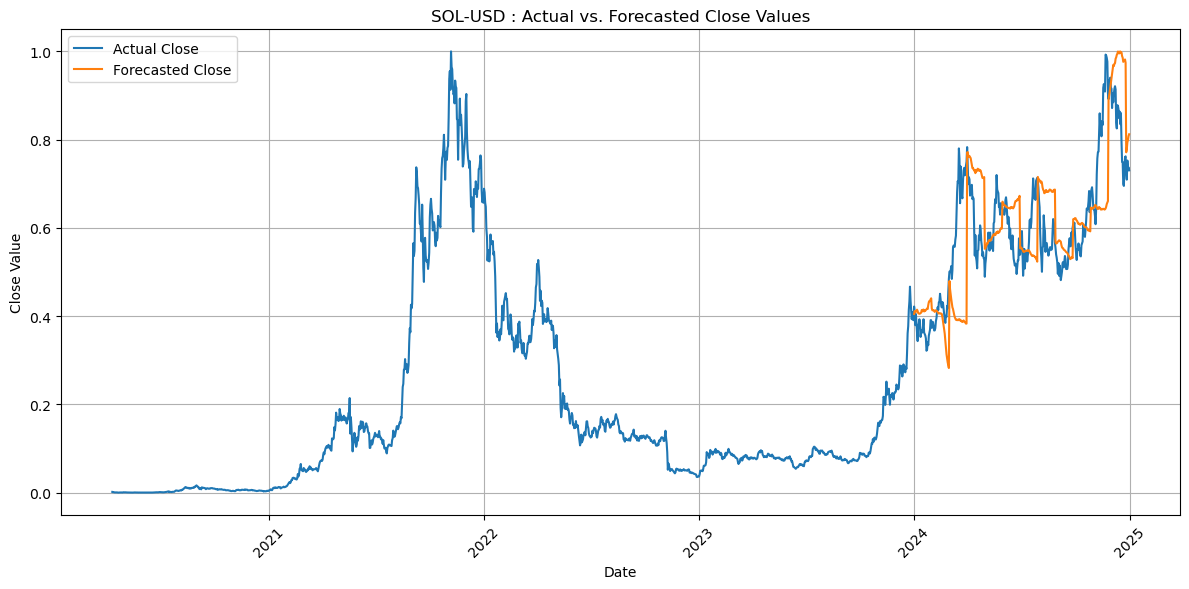

Evaluation Metric for SOL-USD_timesfm_30 Scaled
MAPE: 15.029545732202271
ME: -0.0018581584174421906
MAE: 0.09290596084731802
MPE: -1.821987000424206
RMSE: 0.12647696564653826
R: 0.6547066319093215
Scalar Product: 0.02861525112883017
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


34222

In [48]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 'm')
gc.collect()

60e7096c-8a72-4337-aa2f-ed995ebd0676


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 81.06531429290771 seconds


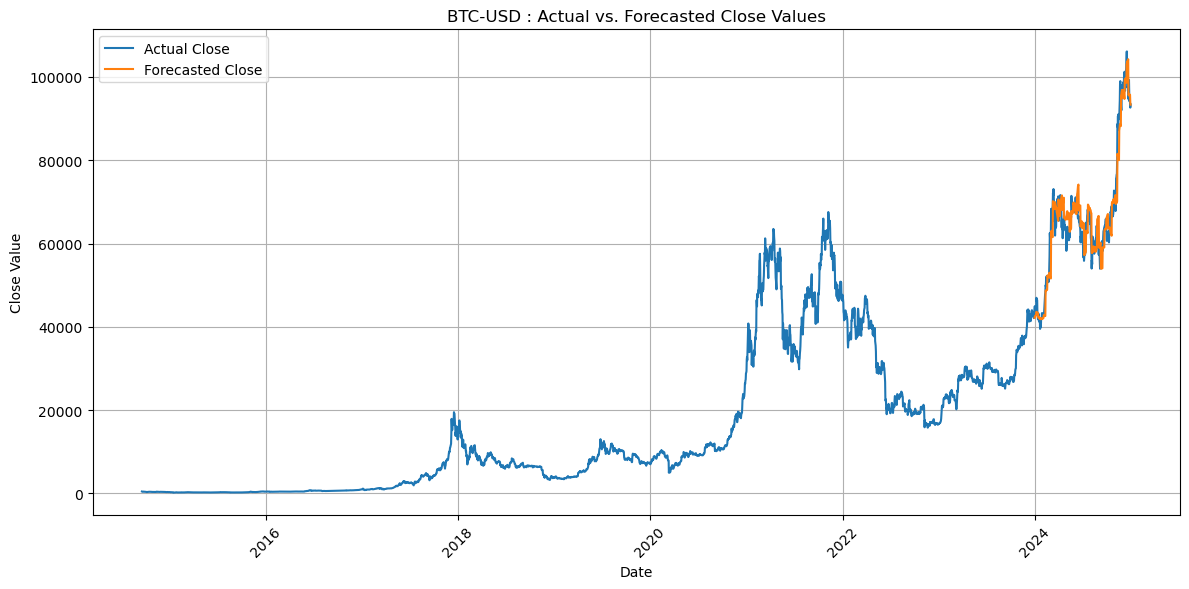

Evaluation Metric for BTC-USD_timesfm_7 Actual Values
MAPE: 5.009039953182882
ME: 75.66859844603833
MAE: 3295.2232859460382
MPE: -0.09383016688471034
RMSE: 4176.583795778342
R: 0.9588768757293695
Scalar Product: 175646733.85986334
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714


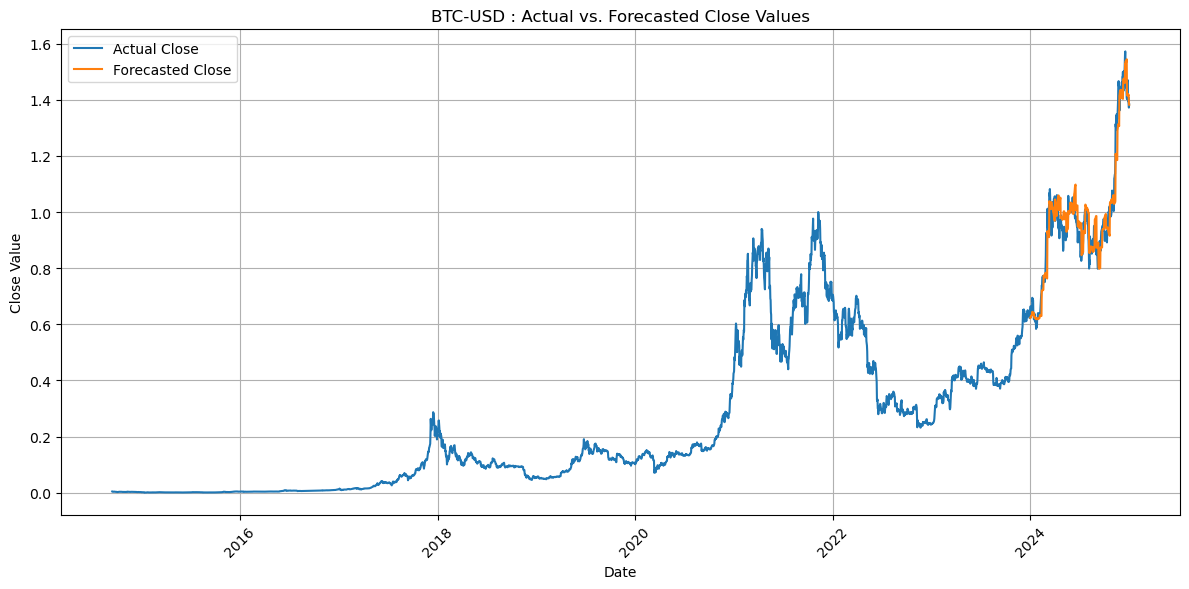

Evaluation Metric for BTC-USD_timesfm_7 Scaled
MAPE: 5.023139690750087
ME: 0.0011228537448880428
MAE: 0.04889873862699701
MPE: -0.09448575631621914
RMSE: 0.06197748915543556
R: 0.9588768740356393
Scalar Product: 0.038678170758289054
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714
Execution time for forecast_crypto_prices(): 160.4392650127411 seconds


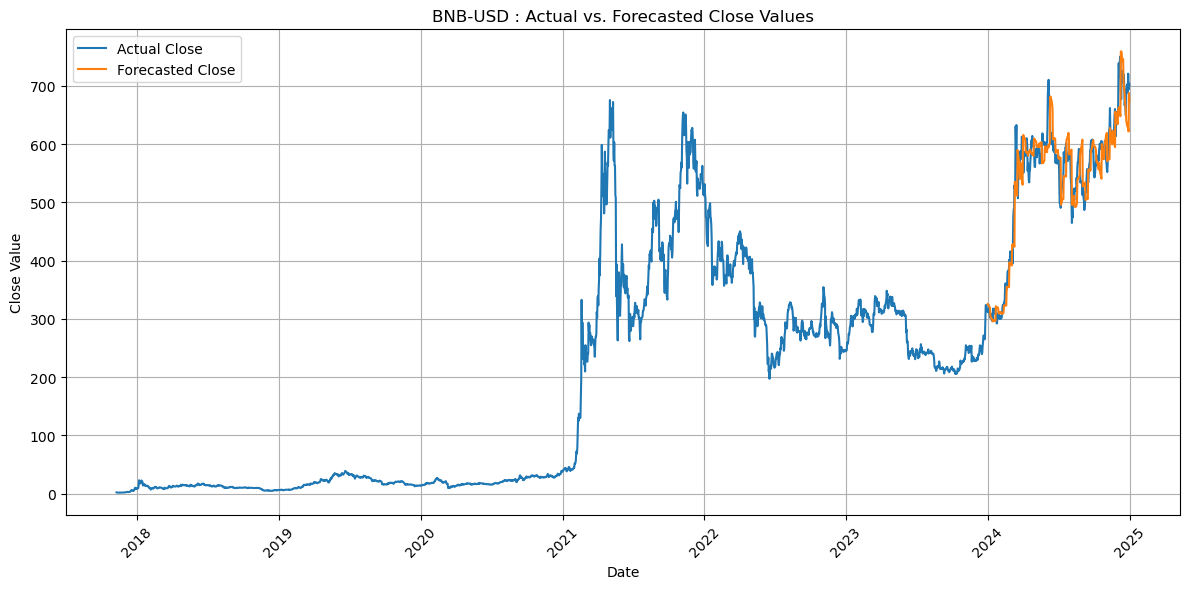

Evaluation Metric for BNB-USD_timesfm_7 Actual Values
MAPE: 5.167334757059549
ME: 3.9348593122972177
MAE: 28.68818406068562
MPE: 0.5243826636982388
RMSE: 37.324532855341864
R: 0.9438947221754804
Scalar Product: -12841.03353317082
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896


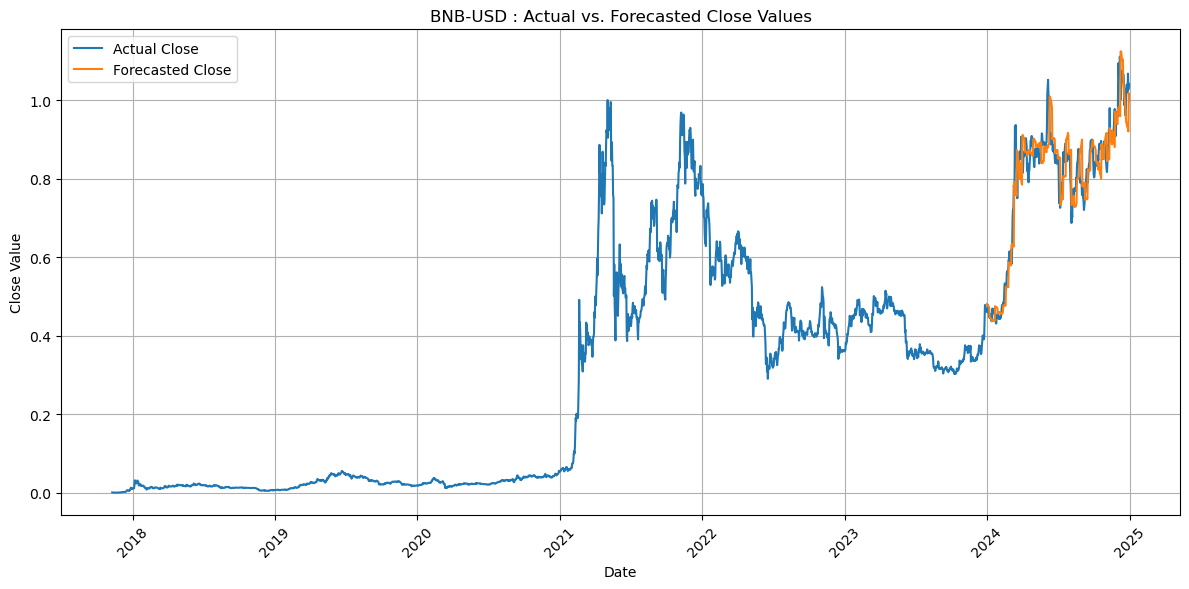

Evaluation Metric for BNB-USD_timesfm_7 Scaled
MAPE: 5.182146164939266
ME: 0.005836553526914494
MAE: 0.04255310210445387
MPE: 0.5254018472604314
RMSE: 0.05536337334778402
R: 0.9438947235774625
Scalar Product: -0.028252460035785538
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896
Execution time for forecast_crypto_prices(): 240.85633993148804 seconds


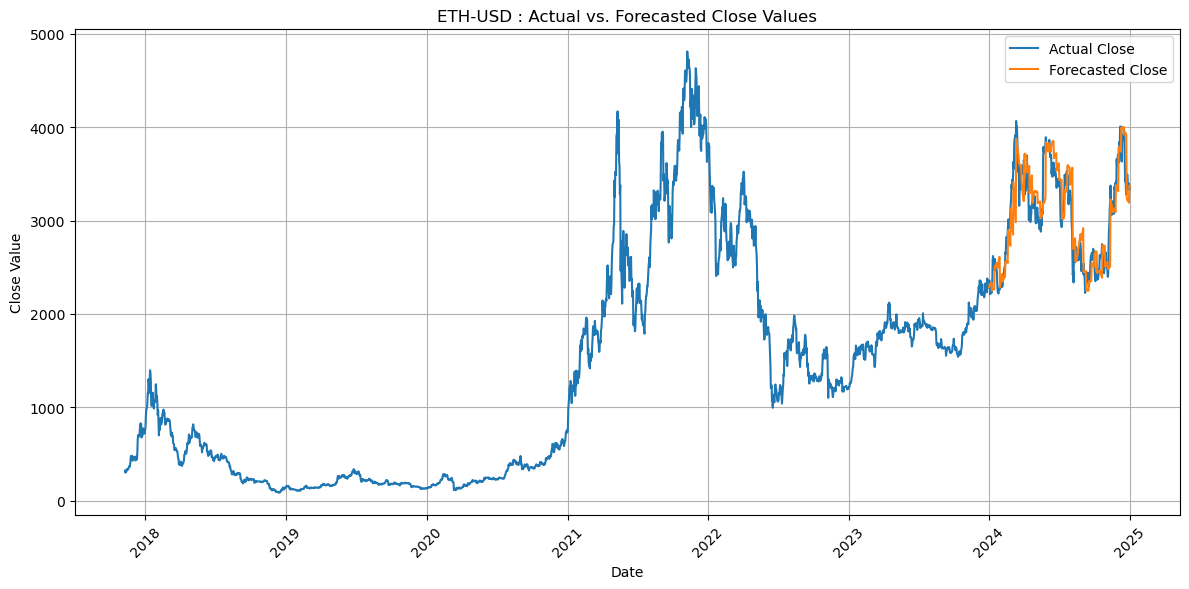

Evaluation Metric for ETH-USD_timesfm_7 Actual Values
MAPE: 6.431691722324484
ME: -17.162252123890024
MAE: 196.34166746712773
MPE: -0.8668564108800227
RMSE: 255.2010971952982
R: 0.8770788586619204
Scalar Product: 354543.94114160514
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873


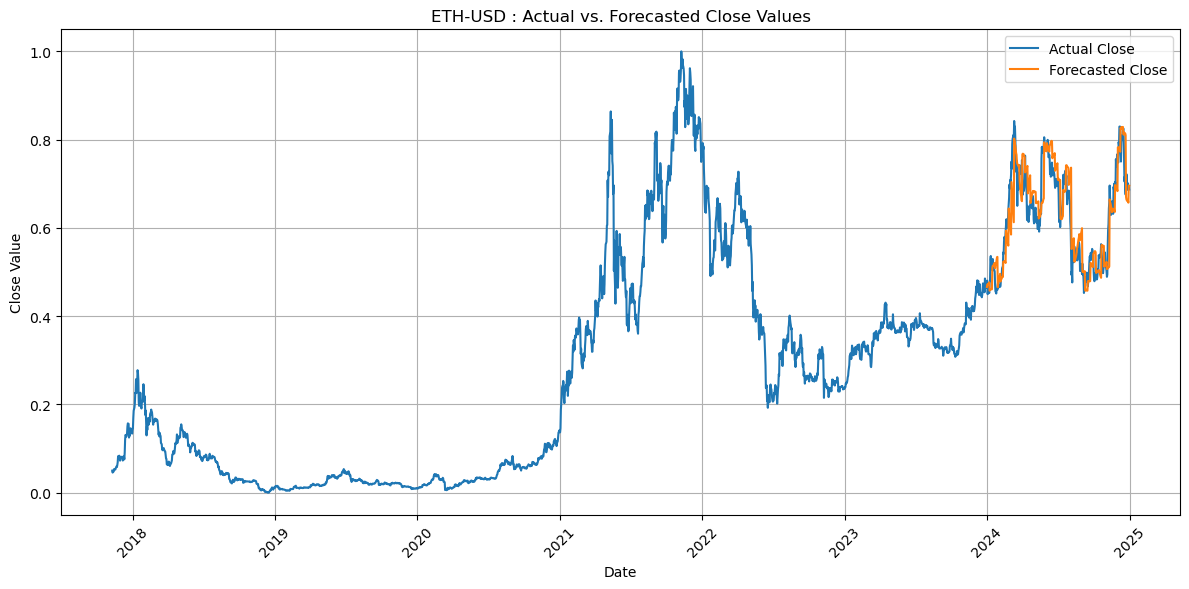

Evaluation Metric for ETH-USD_timesfm_7 Scaled
MAPE: 6.619799535313906
ME: -0.0036301034166534353
MAE: 0.04152936783282272
MPE: -0.9011314846881823
RMSE: 0.053979065882264775
R: 0.8770788678534495
Scalar Product: 0.015861930312311215
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873
Execution time for forecast_crypto_prices(): 320.427405834198 seconds


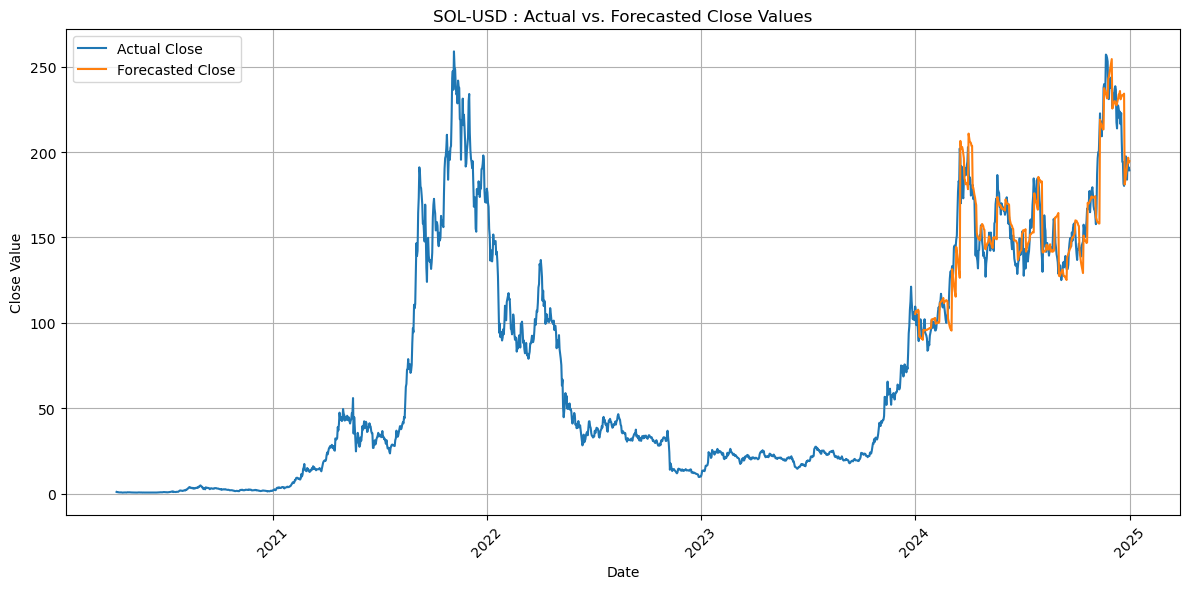

Evaluation Metric for SOL-USD_timesfm_7 Actual Values
MAPE: 6.731040698101491
ME: -0.7168536577068396
MAE: 10.448776120045146
MPE: -0.7974380589764926
RMSE: 15.112495341435752
R: 0.9202504550246227
Scalar Product: 379.17284260609233
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


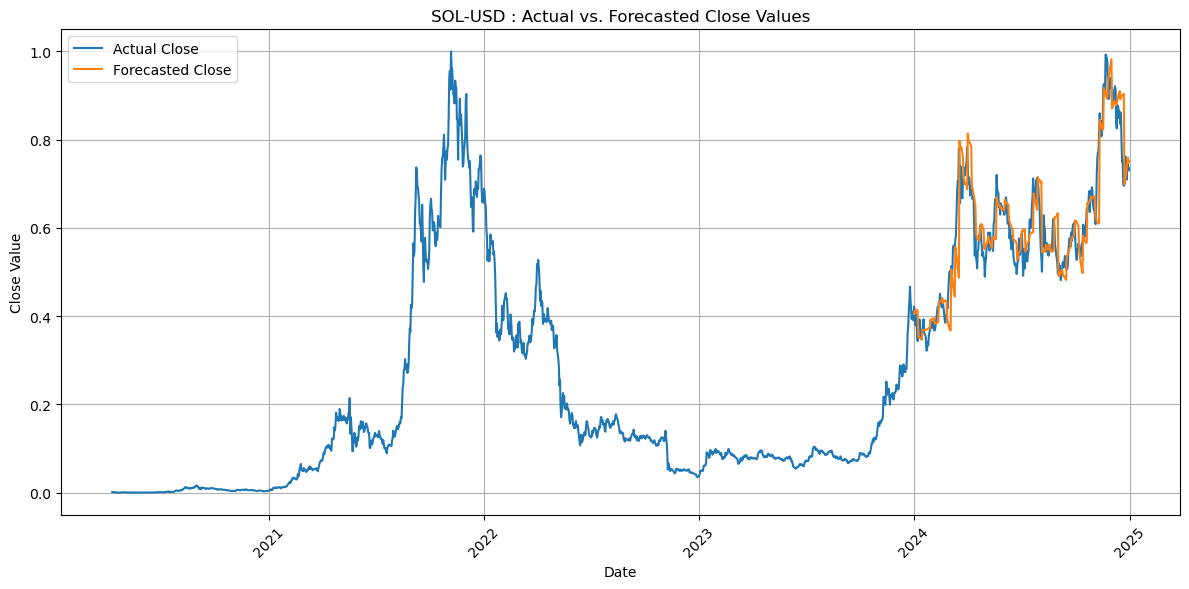

Evaluation Metric for SOL-USD_timesfm_7 Scaled
MAPE: 6.754750307261324
ME: -0.0027739868786462608
MAE: 0.04043345818270888
MPE: -0.8014932667778727
RMSE: 0.05848057626036638
R: 0.9202504565324633
Scalar Product: 0.005677913985383947
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


34220

In [49]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = 'm')
gc.collect()

d0a3f122-adc6-44f1-b13d-6e6a00b36747


Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 1493.34it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 527.3165230751038 seconds


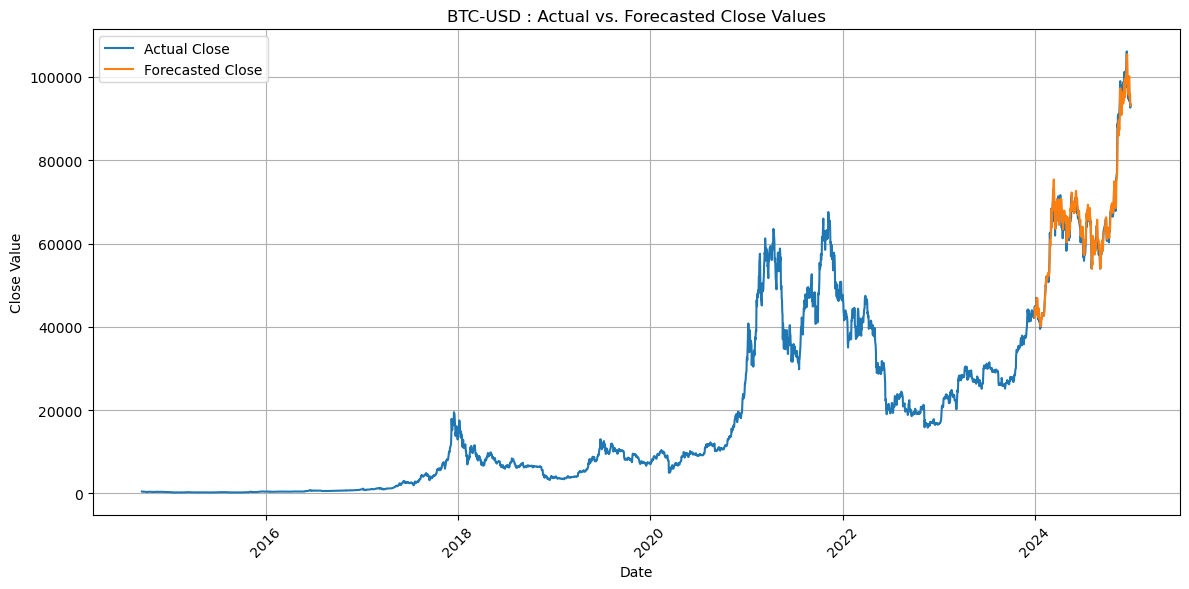

Evaluation Metric for BTC-USD_timesfm_1 Actual Values
MAPE: 2.5363817677982197
ME: -304.9631681181692
MAE: 1688.073653090847
MPE: -0.6222135030334794
RMSE: 2211.6001066954373
R: 0.9889288769898211
Scalar Product: -22504554.47644048
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713


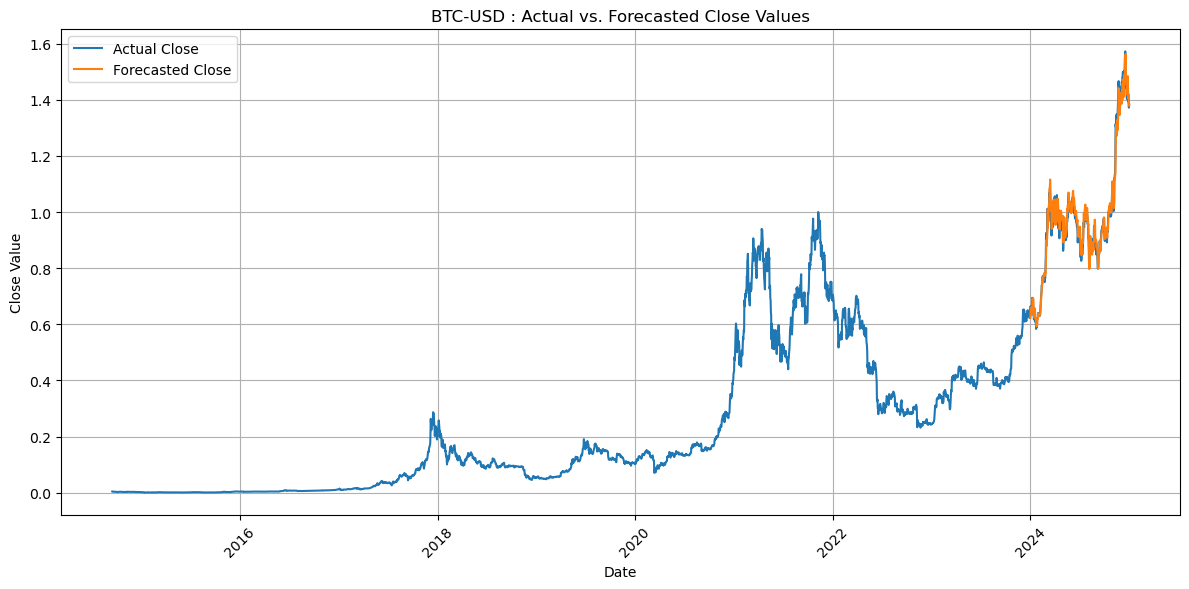

Evaluation Metric for BTC-USD_timesfm_1 Scaled
MAPE: 2.5434964013042265
ME: -0.004525445411102892
MAE: 0.025049793659319815
MPE: -0.6242972199353599
RMSE: 0.032818547193042974
R: 0.9889288771997731
Scalar Product: -0.004955627355195202
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713
Execution time for forecast_crypto_prices(): 1066.7003419399261 seconds


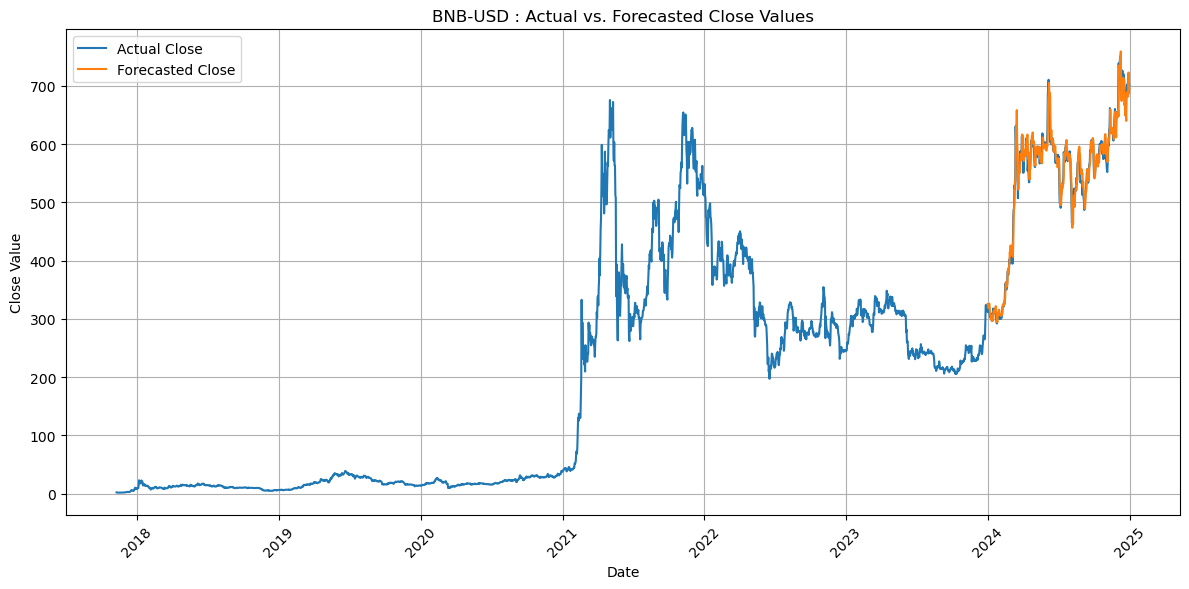

Evaluation Metric for BNB-USD_timesfm_1 Actual Values
MAPE: 2.401752058679384
ME: -0.8367630588552328
MAE: 13.097126694976307
MPE: -0.2649516956469029
RMSE: 18.704923057815172
R: 0.9857736562157289
Scalar Product: -2817.501103655406
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586


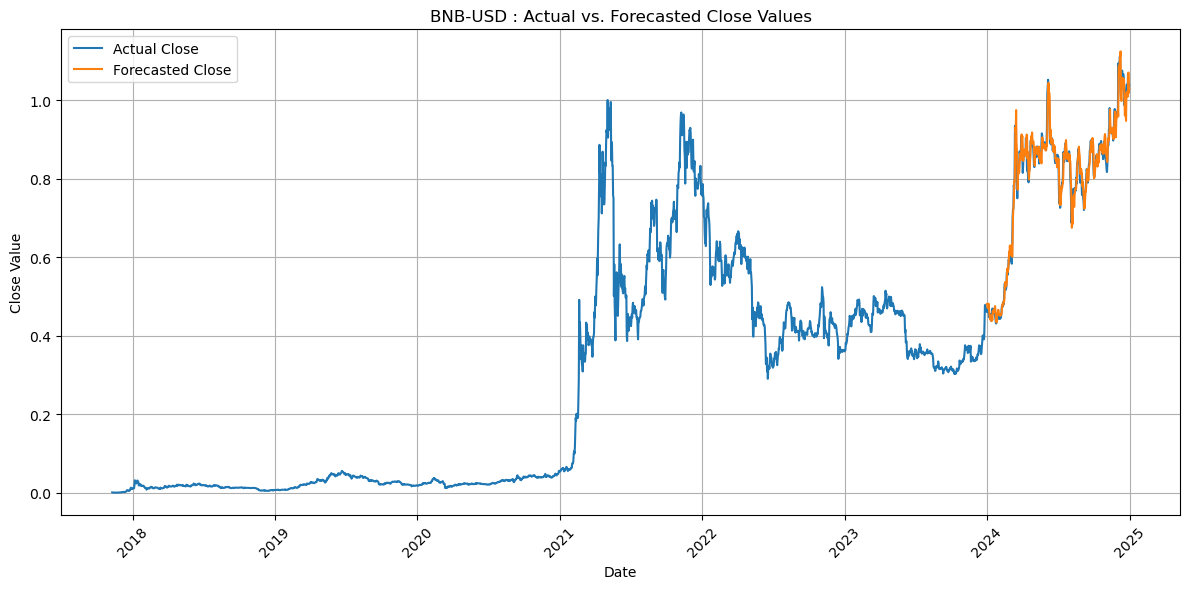

Evaluation Metric for BNB-USD_timesfm_1 Scaled
MAPE: 2.4087882856793663
ME: -0.001241181125849664
MAE: 0.01942693030362721
MPE: -0.2660841897526529
RMSE: 0.027744959432052838
R: 0.9857736575641823
Scalar Product: -0.00619898361015803
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 1605.6464672088623 seconds


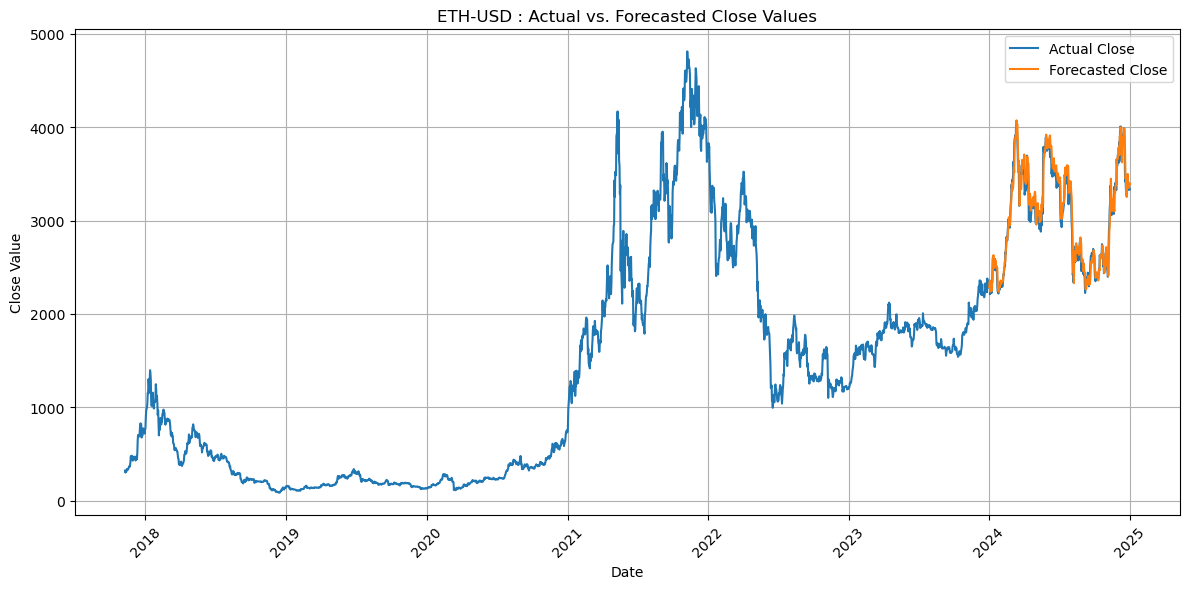

Evaluation Metric for ETH-USD_timesfm_1 Actual Values
MAPE: 2.920083374829985
ME: -29.457592906847673
MAE: 89.08331999231557
MPE: -0.9997350803085885
RMSE: 118.7580079671185
R: 0.9751251317740665
Scalar Product: -49551.557645022214
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586


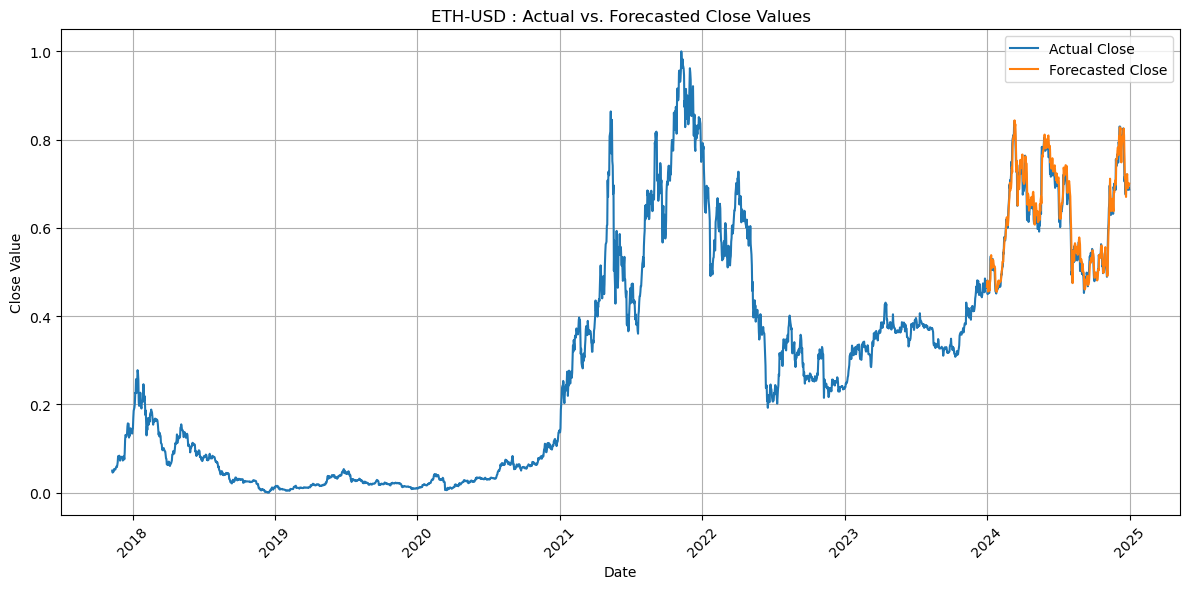

Evaluation Metric for ETH-USD_timesfm_1 Scaled
MAPE: 3.005371410522023
ME: -0.006230761307708057
MAE: 0.01884253460386676
MPE: -1.0297509829694025
RMSE: 0.025119199428370893
R: 0.9751251342086719
Scalar Product: -0.0022168774454487073
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 2140.4733216762543 seconds


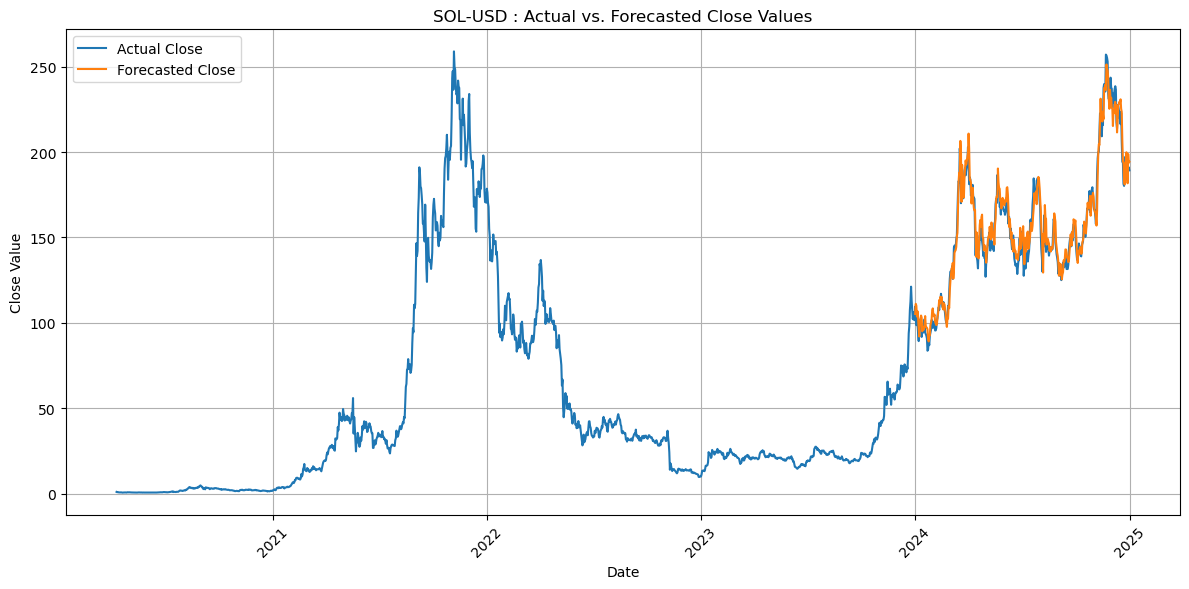

Evaluation Metric for SOL-USD_timesfm_1 Actual Values
MAPE: 3.9940191182698546
ME: -1.5554049549207016
MAE: 6.099092952540664
MPE: -1.343213567048037
RMSE: 7.804244309806163
R: 0.9787222393873594
Scalar Product: -981.3135454129633
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


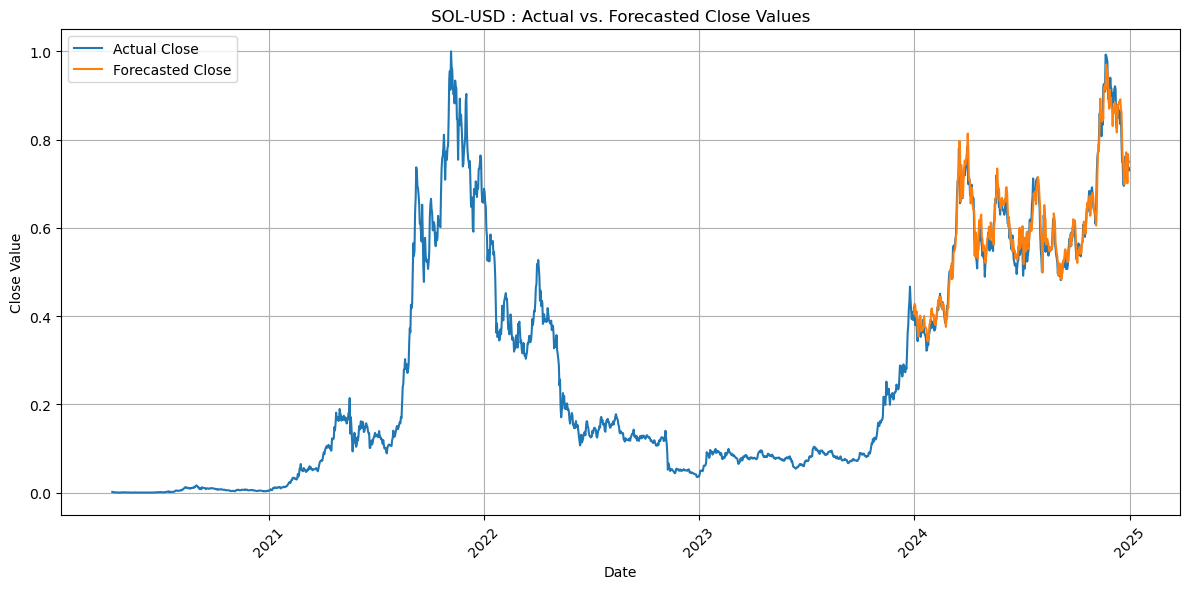

Evaluation Metric for SOL-USD_timesfm_1 Scaled
MAPE: 4.008410724008233
ME: -0.006018914225026943
MAE: 0.02360155817718642
MPE: -1.3491685518238996
RMSE: 0.030199954483316936
R: 0.978722239948071
Scalar Product: -0.014694632912331173
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


34226

In [50]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = 'm')
gc.collect()